In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp
import sympy

C:\Users\muliy\AppData\Local\Temp\ipykernel_8560\3600640902.py:122: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


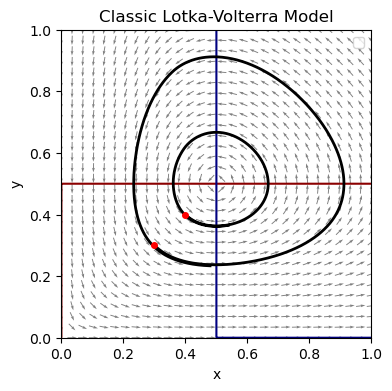

In [2]:
class PhasePlotter2D:
    def __init__(self, model, params=None):
        self.model = model
        self.params = params or ()
        self.solution = None

    def solve(self, init_cond, t_span=(0, 20), t_eval=None):
        self.solution = solve_ivp(
            lambda t, y: self.model(t, y, *self.params),
            t_span,
            init_cond,
            t_eval=t_eval
        )
        return self.solution
    
    def plot_solve(self, ax, init_conds, t_end=20, dt=0.01, color='black', lw=2):

        init_conds = np.atleast_2d(init_conds)
        t_eval = np.arange(0, t_end, dt)

        for init in init_conds:
            sol = solve_ivp(
                lambda t, y: self.model(t, y, *self.params),
                (0, t_end),
                init,
                t_eval=t_eval
            )
            ax.plot(sol.y[0], sol.y[1], color=color, lw=lw)
            ax.plot(sol.y[0][0], sol.y[1][0], 'ro', markersize=4)  # 起点标记

        return ax

    def plot_phase_diagram(self, x_range, y_range, density=1.5, ax=None):
        """绘制相图与向量场"""
        ax = ax or plt.gca()
        
        # 生成网格
        x = np.linspace(*x_range, int(20*density))
        y = np.linspace(*y_range, int(20*density))
        X, Y = np.meshgrid(x, y)
        
        # 计算向量场
        DX, DY = self.model(0, np.array([X, Y]), *self.params)
        norm = np.hypot(DX, DY) + 1e-8
        
        ax.quiver(X, Y, DX/norm, DY/norm, 
                 color='gray', 
                 scale=50/density,
                 width=0.003,
                 pivot='mid')
        
        if self.solution:
            ax.plot(self.solution.y[0], self.solution.y[1], 
                   'b-', lw=2, label='Solution')
            ax.plot(self.solution.y[0][0], self.solution.y[1][0], 'ro')
            
        ax.set(xlim=x_range, ylim=y_range,
              xlabel='x', ylabel='y')
        return ax

    def plot_nullclines(self, x_range, y_range, resolution=500, ax=None):
        ax = ax or plt.gca()
        x = np.linspace(*x_range, resolution)
        y = np.linspace(*y_range, resolution)
        X, Y = np.meshgrid(x, y)
        
        # 创建空的数组存储零增长曲线的结果
        DX = np.zeros_like(X)
        DY = np.zeros_like(Y)
        
        # 对每个点计算 dx/dt 和 dy/dt
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                dxdt, dydt = self.model(0, [X[i, j], Y[i, j]], *self.params)
                DX[i, j], DY[i, j] = dxdt, dydt

        # 绘制 dx/dt = 0 和 dy/dt = 0 的曲线
        ax.contour(X, Y, DX, levels=[0], colors='darkred', linewidths=1.5)
        ax.contour(X, Y, DY, levels=[0], colors='navy', linewidths=1.5)
        
        # 添加图例
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='darkred', lw=1.5, label='dx/dt=0'),
            Line2D([0], [0], color='navy', lw=1.5, label='dy/dt=0')
        ]
        ax.legend(handles=legend_elements)
        return ax

# 使用示例
if __name__ == "__main__":
    # 定义微分方程函数
    def lv_2species(t, vars, r1, r2, a1, a2):
        x, y = vars
        return np.array([
            r1*x #- x**2 
            - a1 * x * y,
            r2*y #- y**2 
            - a2 * y * x
        ])
    
    # 设置参数

    params = (0.5,-0.5,1,-1) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(lv_2species, params=params)
    
    # 数值求解
    #plotter.solve([0.2, 0.8], t_span=(0, 50))
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(4, 4))
    
    # 绘制图形
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

    ax = plotter.plot_solve(ax, [[0.3,0.3]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.4,0.4]], t_end=15, dt=0.01)
    
    ax.legend()
    plt.title("Classic Lotka-Volterra Model")
    plt.show()


C:\Users\muliy\AppData\Local\Temp\ipykernel_8560\3886572384.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


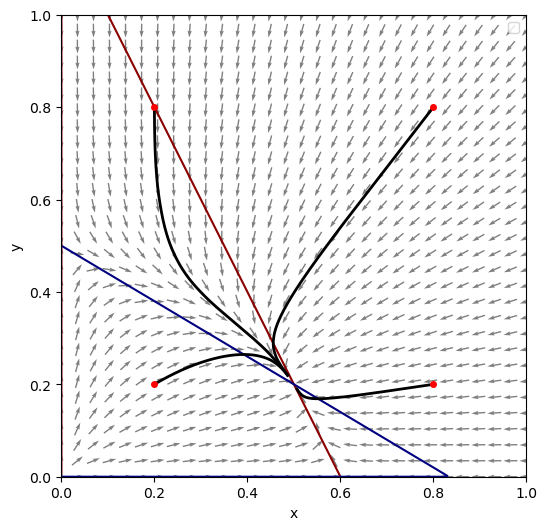

In [3]:
# 使用示例
if __name__ == "__main__":
    # 定义微分方程函数
    def glv_2species(t, vars, r1, r2, a1, a2):
        x, y = vars
        return np.array([
            r1*x - x**2 - a1 * x * y,
            r2*y - y**2 - a2 * y * x
        ])
    
    # 设置参数

    params = (0.6,0.5,0.5,0.6) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(glv_2species, params=params)
    
    # 数值求解
    #plotter.solve([0.2, 0.8], t_span=(0, 50))
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # 绘制图形
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

    plotter.plot_solve(ax, [[0.2,0.2]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.2,0.8]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.8,0.8]], t_end=15, dt=0.01)
    ax = plotter.plot_solve(ax, [[0.8,0.2]], t_end=15, dt=0.01)
    
    ax.legend()
    plt.show()


C:\Users\muliy\AppData\Local\Temp\ipykernel_8560\2502316671.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


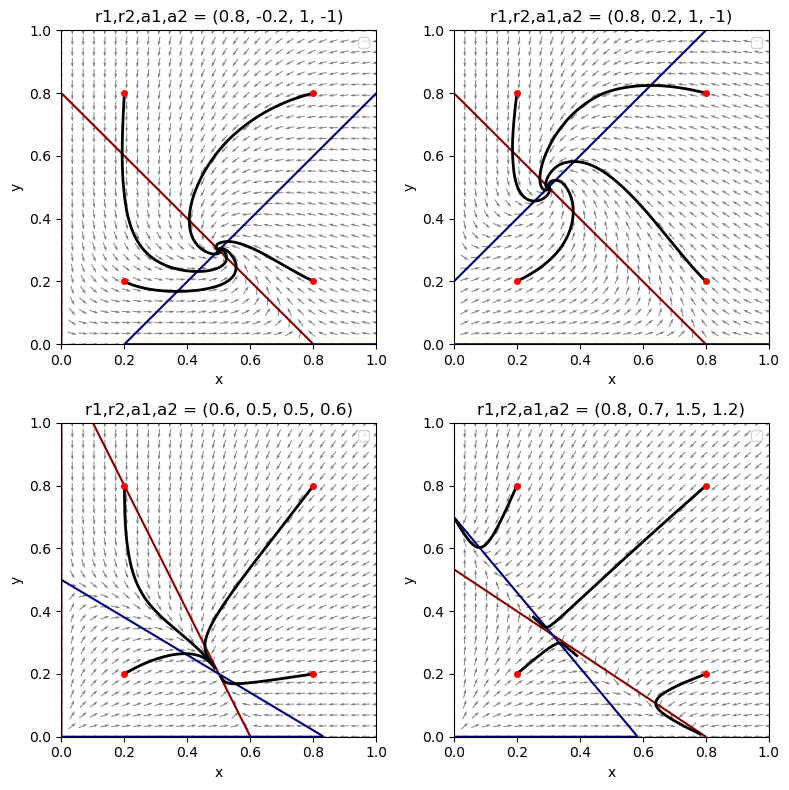

In [4]:
if __name__ == "__main__":

    params_a = [(0.8,-0.2,1,-1), (0.8,0.2,1,-1), (0.6,0.5,0.5,0.6), (0.8,0.7,1.5,1.2)]
    
    # 创建 2x2 子图
    fig, axes = plt.subplots(2, 2, figsize=(8, 8))
    axes = axes.flatten()

    
    # 遍历不同的 b 值
    for i in range(0,4):
        ax = axes[i]
        
        # 创建绘图器
        plotter = PhasePlotter2D(glv_2species, params=params_a[i])
        
        # 绘制相图和零流线
        plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
        plotter.plot_nullclines((0, 1), (0, 1), ax=ax)
        
        # 绘制轨迹
        plotter.plot_solve(ax, [0.2,0.2], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.2,0.8], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.8,0.2], t_end=15, dt=0.01)

        plotter.plot_solve(ax, [0.8,0.8], t_end=15, dt=0.01)
        
        ax.set_title(f"r1,r2,a1,a2 = {params_a[i]}")
        ax.legend()
    
    plt.tight_layout()
    plt.show()

In [5]:
def laplacian_1d(u, dx):
    """一维二阶中心差分拉普拉斯算子，零通量边界条件。"""
    lap = np.zeros_like(u)
    lap[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
    lap[0] = (u[1] - u[0]) / dx**2
    lap[-1] = (u[-2] - u[-1]) / dx**2
    return lap


class ReactionDiffusion1D:
    """多物种反应-扩散一维模型。
    
    参数
    ----
    D : ndarray, shape (n,)
        各物种扩散系数
    r : ndarray, shape (n,)
        各物种内禀增长率
    A : ndarray, shape (n, n)
        相互作用矩阵
    xspan : tuple
        空间区间 (xmin, xmax)
    nx : int
        空间网格数
    dt : float
        时间步长
    """
    
    def __init__(self, D, r, A, xspan=(0, 1), nx=200, dt=1e-4):
        self.D = np.array(D)
        self.r = np.array(r)
        self.A = np.array(A)
        self.n = len(D)
        
        self.xmin, self.xmax = xspan
        self.nx = nx
        self.dt = dt
        
        self.x = np.linspace(self.xmin, self.xmax, nx)
        self.dx = self.x[1] - self.x[0]

        self.N = np.zeros((self.n, self.nx))
    
    def set_initial(self, N0):
        """设置初值 N0，形状应为 (n, nx)。"""
        self.N = np.array(N0).copy()
    
    def reaction_term(self, N):
        """Lotka–Volterra 型的反应部分。"""
        interaction = self.A @ N
        return N * self.r[:, None] * (1 - interaction)
    
    def diffusion_term(self, N):
        """扩散项，每个物种一个拉普拉斯算子。"""
        diff = np.zeros_like(N)
        for i in range(self.n):
            diff[i] = self.D[i] * laplacian_1d(N[i], self.dx)
        return diff
    
    def step(self):
        """单步前进。"""
        R = self.reaction_term(self.N)
        D = self.diffusion_term(self.N)
        self.N += self.dt * (R + D)
        self.N = np.maximum(self.N, 0.0)
    
    def run(self, steps, record_interval=None):
        """运行 steps 步，如果给定 record_interval 则返回记录列表。"""
        if record_interval is None:
            for _ in range(steps):
                self.step()
            return None
        
        records = []
        for k in range(steps):
            self.step()
            if k % record_interval == 0:
                records.append(self.N.copy())
        return records


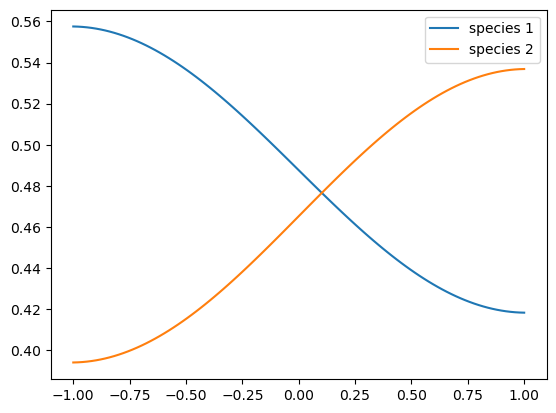

In [6]:
n = 2

a=0.1
a2=1+a
b=0.5
D = [0.1, 0.1]
r = [(1-b), 1]
A = np.array([[1, a2],
              [a2, 1]])

model = ReactionDiffusion1D(D, r, A, xspan=(-1, 1), nx=100, dt=1e-4)

x = model.x
N0 = np.zeros((n, len(x)))
N0[0] = 1
N0[0][x>=0] = 0
N0[1] = 1
N0[1][x<=0] = 0

model.set_initial(N0)

records = model.run(steps=100000, record_interval=10)

plt.plot(x, records[-1][0], label='species 1')
plt.plot(x, records[-1][1], label='species 2')
plt.legend()
plt.show()


In [157]:
n = 2

# 可调步长
da = 0.05
db = 0.05

a_list = np.arange(da, 1 , da)
b_list = np.arange(db, 1 , db)

results = {}

for a in a_list:
    for b in b_list:

        D = [0.1, 0.1]
        r = [1 *(1- b), 1]
        A = np.array([[1, 1+a],
                      [1+a, 1]])

        model = ReactionDiffusion1D(D, r, A, xspan=(-1, 1), nx=100, dt=1e-4)

        x = model.x
        N0 = np.zeros((n, len(x)))
        N0[0] = 1
        N0[0][x > 0] = 0
        N0[1] = 1
        N0[1][x < 0] = 0

        model.set_initial(N0)

        records = model.run(steps=100000, record_interval=10)

        # 保存最终状态
        final_state = records[-1]

        results[(a, b)] = final_state

print("Simulation finished")

Simulation finished


In [158]:
import pickle

# 保存
with open("results_rk.pkl", "wb") as f:
    pickle.dump(results, f)

print("results 已保存为 results.pkl")

results 已保存为 results.pkl


In [159]:
def get_equal_front(x, u1, u2):

    diff = u1 - u2

    # 找符号变化
    sign_change = np.where(diff[:-1] * diff[1:] <= 0)[0]

    if len(sign_change) > 0:

        i = sign_change[0]

        x1, x2 = x[i], x[i+1]
        y1, y2 = diff[i], diff[i+1]

        # 线性插值
        xf = x1 - y1 * (x2 - x1) / (y2 - y1)

        return xf

    # 如果没有交点
    left = diff[0]
    right = diff[-1]

    if left > 0 and right > 0:
        return -1     # species1 everywhere

    if left < 0 and right < 0:
        return 1      # species2 everywhere

    return np.nan

In [160]:
front_map = np.zeros((len(a_list), len(b_list)))

for i, a in enumerate(a_list):
    for j, b in enumerate(b_list):

        final_state = results[(a,b)]

        u1 = final_state[0]
        u2 = final_state[1]

        front = get_equal_front(x, u1, u2)

        front_map[i, j] = front

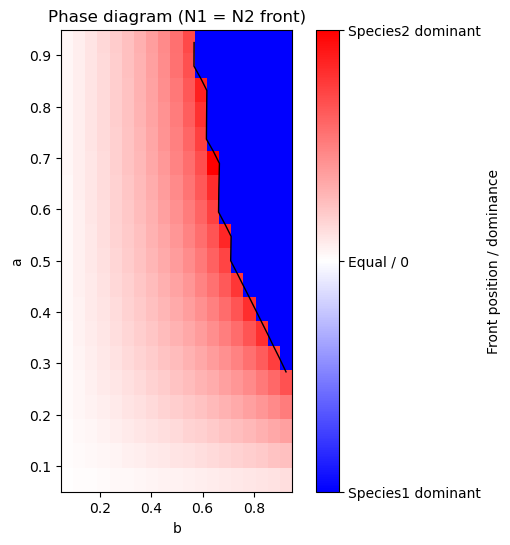

In [161]:
plt.figure(figsize=(6,6))

# 计算最大绝对值，保证 colormap 对称
max_abs = np.nanmax(np.abs(front_map))

# 绘制 heatmap，使用连续的 diverging colormap
im = plt.imshow(front_map,
                origin='lower',
                extent=[b_list[0], b_list[-1],
                        a_list[0], a_list[-1]],
                aspect=(b_list[-1]-b_list[0])/(a_list[-1]-a_list[0])*2,
                cmap='bwr',  # blue-white-red
                vmin=-max_abs,
                vmax=+max_abs)

plt.xlabel("b")
plt.ylabel("a")
plt.title("Phase diagram (N1 = N2 front)")

# 添加颜色条
cbar = plt.colorbar(im, label="Front position / dominance")
cbar.set_ticks([-max_abs, 0, max_abs])
cbar.set_ticklabels(['Species1 dominant', 'Equal / 0', 'Species2 dominant'])

# 可选：在图上加一条零值轮廓线，让正负分界清楚
plt.contour(front_map, levels=[0], colors='k', linewidths=1,
            origin='lower',
            extent=[b_list[0], b_list[-1],
                    a_list[0], a_list[-1]])

plt.show()

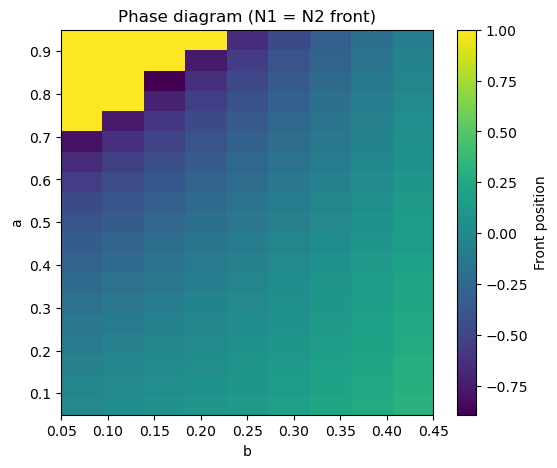

In [139]:
plt.figure(figsize=(6,5))

plt.imshow(front_map,
           origin='lower',
           extent=[b_list[0], b_list[-1],
                   a_list[0], a_list[-1]],
           aspect='auto')

plt.xlabel("b")
plt.ylabel("a")

plt.colorbar(label="Front position")

plt.title("Phase diagram (N1 = N2 front)")

plt.show()

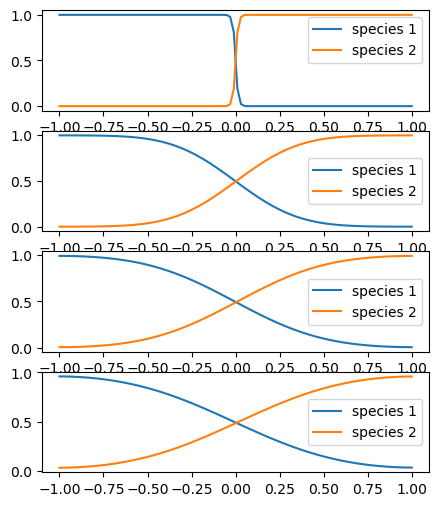

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(5, 6))
axes = axes.flatten()

for i in range(0,4):
    ax = axes[i]
    record = records[1+400*i]
    ax.plot(x, record[0], label='species 1')
    ax.plot(x, record[1], label='species 2')
    ax.legend()

plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_8560\1897325086.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


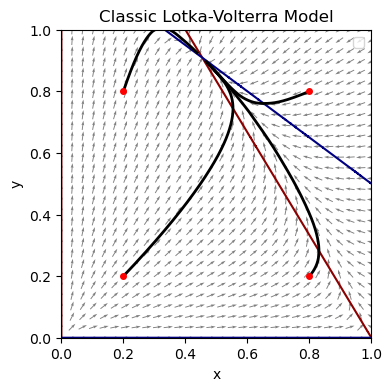

In [31]:
if __name__ == "__main__":
    # 定义微分方程函数
    def lv_2species(t, vars):
        x, y = vars
        return np.array([
            x - x**2 
            - 0.6 * x * y,
            y - 0.8*y**2 
            - 0.6* y * x
        ])
    
    
    # 初始化绘图器
    plotter = PhasePlotter2D(lv_2species)
    
    # 数值求解
    #plotter.solve([0.2, 0.8], t_span=(0, 50))
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(4, 4))
    
    # 绘制图形
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

    plotter.plot_solve(ax, [0.2,0.2], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.2,0.8], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.8,0.2], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.8,0.8], t_end=15, dt=0.01)
    
    ax.legend()
    plt.title("Classic Lotka-Volterra Model")
    plt.show()

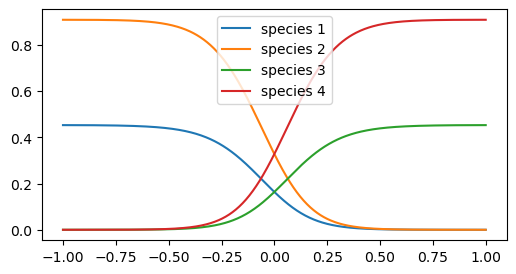

In [38]:
n = 4
D = [0.01, 0.01, 0.01, 0.01]
r = [1, 1.1, 1, 1.1]
A = np.array([[ 1.0,    0.6,    1.5,    1.5],
              [ 0.6,    0.8,    1.5,    1.5],
              [ 1.5,    1.5,    1.0,    0.6],
              [ 1.5,    1.5,    0.6,    0.8]])

model = ReactionDiffusion1D(D, r, A, xspan=(-1, 1), nx=500, dt=5e-4)

x = model.x
N0 = np.zeros((n, len(x)))
N0[0] = 1
N0[0][x>0] = 0
N0[1] = 1
N0[1][x>0] = 0
N0[2] = 1
N0[2][x<=0] = 0
N0[3] = 1
N0[3][x<=0] = 0

model.set_initial(N0)

records = model.run(steps=200000, record_interval=500)


fig, ax = plt.subplots(figsize=(6, 3))

plt.plot(x, records[-1][0], label='species 1')
plt.plot(x, records[-1][1], label='species 2')
plt.plot(x, records[-1][2], label='species 3')
plt.plot(x, records[-1][3], label='species 4')
plt.legend()
plt.show()

In [57]:
N = np.array(records[-1])   # shape = (n_species, n_x)

# ----------------------------
# 1. 计算 p_i = N_i / sum_i N_i
# ----------------------------

sum_N = np.sum(N, axis=0)   # 对每个 x，把所有 i 的 N_i 相加，shape = (n_x,)

# 避免除零
sum_N_safe = np.where(sum_N == 0, 1, sum_N)

p = N / sum_N_safe          # shape = (n_species, n_x)

# ----------------------------
# 2. 计算熵分布 S(x) = -sum_i p_i ln p_i
# ----------------------------

# 避免 log(0)
p_safe = np.where(p > 0, p, 1)

entropy_x = -np.sum(p * np.log(p_safe), axis=0)

# entropy_x 的 shape = (n_x,)
# 表示每个 x 点上的熵
print(entropy_x)

[0.63651705 0.63651773 0.63651908 0.63652111 0.63652383 0.63652723
 0.63653132 0.63653611 0.6365416  0.6365478  0.63655473 0.63656239
 0.63657079 0.63657994 0.63658987 0.63660058 0.63661209 0.63662442
 0.63663759 0.63665161 0.63666651 0.63668232 0.63669905 0.63671672
 0.63673538 0.63675505 0.63677575 0.63679752 0.63682039 0.6368444
 0.63686959 0.63689599 0.63692365 0.63695261 0.63698291 0.6370146
 0.63704772 0.63708234 0.6371185  0.63715626 0.63719568 0.63723682
 0.63727973 0.6373245  0.63737117 0.63741984 0.63747056 0.63752343
 0.63757851 0.63763589 0.63769566 0.63775791 0.63782273 0.63789021
 0.63796047 0.6380336  0.63810972 0.63818893 0.63827135 0.63835711
 0.63844633 0.63853914 0.63863568 0.63873609 0.63884051 0.6389491
 0.63906201 0.6391794  0.63930145 0.63942833 0.63956022 0.63969731
 0.63983979 0.63998787 0.64014175 0.64030165 0.64046779 0.64064041
 0.64081975 0.64100605 0.64119958 0.6414006  0.64160938 0.64182622
 0.64205141 0.64228525 0.64252807 0.64278019 0.64304196 0.6433137

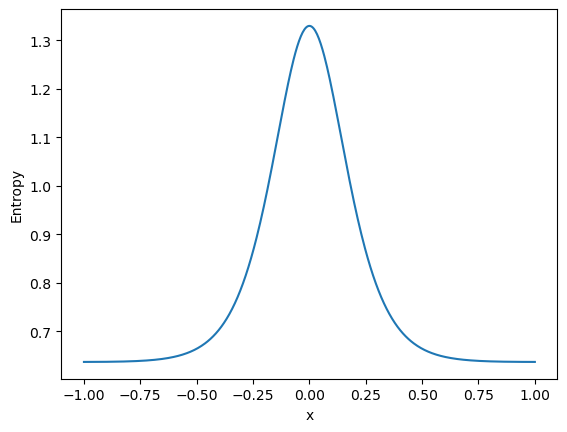

In [ ]:
plt.plot(x, entropy_x)
plt.xlabel('x')
plt.ylabel('Entropy')
plt.show()

In [63]:
# 对每个 i，计算 N_i(x) 在 x 上的积分
integrals = np.trapz(N, x=x, axis=1)

# integrals 的 shape = (n_species,)
# integrals[i] 就是第 i 个 N_i 的积分
print(integrals)

sum_IN = np.sum(integrals, axis=0) 

ip = integrals / sum_IN         # shape = (n_species, n_x)

gamma_div = -np.sum(ip * np.log(ip), axis=0)

# entropy_x 的 shape = (n_x,)
# 表示每个 x 点上的熵
print(gamma_div)

[0.41919553 0.84507222 0.41919553 0.84507222]
1.3284333580705394


In [64]:
alpha_div_avg = np.trapz(entropy_x, x=x)
print(alpha_div_avg)

1.5726692920853216


In [66]:
beta_div = gamma_div/alpha_div_avg
print(beta_div)

0.8446997501356873


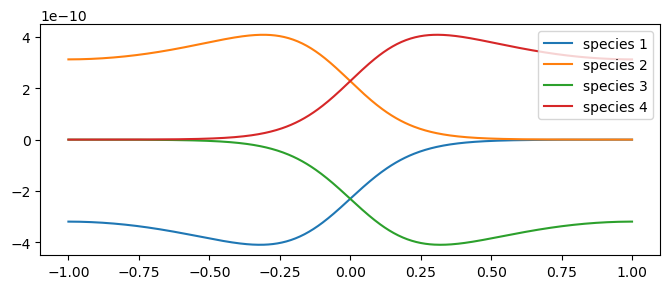

In [53]:
fig, ax = plt.subplots(figsize=(8, 3))

plt.plot(x, records[-1][0]-records[398][0], label='species 1')
plt.plot(x, records[-1][1]-records[398][1], label='species 2')
plt.plot(x, records[-1][2]-records[398][2], label='species 3')
plt.plot(x, records[-1][3]-records[398][3], label='species 4')
plt.legend()
plt.show()

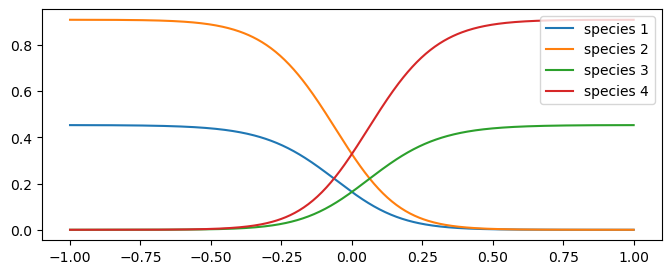

In [56]:
fig, ax = plt.subplots(figsize=(8, 3))

plt.plot(x, records[-1][0], label='species 1')
plt.plot(x, records[-1][1], label='species 2')
plt.plot(x, records[-1][2], label='species 3')
plt.plot(x, records[-1][3], label='species 4')
plt.legend(loc='upper right')
plt.show()

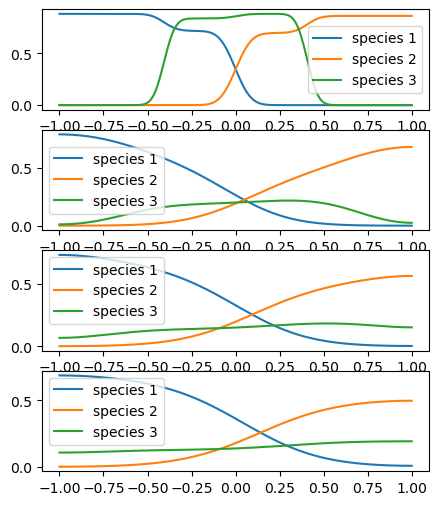

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(5, 6))
axes = axes.flatten()

for i in range(0,4):
    ax = axes[i]
    record = records[1+20*i]
    ax.plot(x, record[0], label='species 1')
    ax.plot(x, record[1], label='species 2')
    ax.plot(x, record[2], label='species 3')
    ax.legend()

plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_13116\2881089017.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


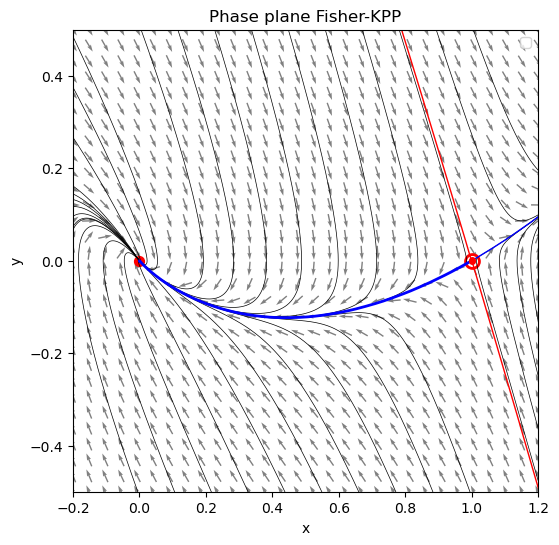

In [114]:
if __name__ == "__main__":
    # 定义微分方程函数
    def Fisher_KPP(t, vars, c):
        u, p = vars
        return np.array([
            p,
            -c*p - u*(1-u)
        ])
    
    # 设置参数

    params = (2,) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(Fisher_KPP, params=params)
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in np.linspace(0, 1, 10):
        ax = plotter.plot_solve(ax, [i,0.51], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [i,-0.51], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [1.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [-0.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
    
    ax = plotter.plot_solve(ax, [[1,-0.001]], t_end=100, dt=0.01, color='blue',lw=2)
    ax = plotter.plot_solve(ax, [[1,0.001]], t_end=100, dt=0.01, color='blue',lw = 1)
    ax = plotter.plot_solve(ax, [[1.208,-0.51]], t_end=10, dt=0.01, color='red',lw = 1)
    ax = plotter.plot_solve(ax, [[0.785,0.51]], t_end=10, dt=0.01, color='red',lw = 1)

    plotter.plot_phase_diagram((-0.2, 1.2), (-0.5, 0.5), ax=ax,density=1.5)
    #plotter.plot_nullclines((-0.2, 1.2), (-0.2, 1.2), ax=ax)
    ax.scatter(0, 0, color='red', s=50)
    ax.scatter(1, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
    
    ax.legend()
    plt.title("Phase plane Fisher-KPP")
    plt.show()

C:\Users\muliy\AppData\Local\Temp\ipykernel_13116\2032100808.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


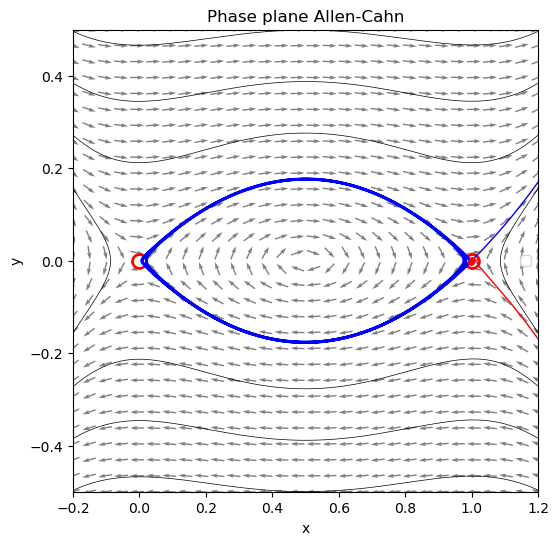

In [193]:
if __name__ == "__main__":
    # 定义微分方程函数
    def Fisher_KPP(t, vars, c):
        u, p = vars
        return np.array([
            p,
            -c*p - u*(1-u)*(u-0.5)
            #-c*p+u**2-u**3
        ])
    
    # 设置参数

    params = (0,) 
    
    # 初始化绘图器
    plotter = PhasePlotter2D(Fisher_KPP, params=params)
    
    # 创建画布
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in np.linspace(0, 1, 10):
        #ax = plotter.plot_solve(ax, [i,0.51], t_end=10, dt=0.01, lw = 0.5)
        #ax = plotter.plot_solve(ax, [i,-0.51], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [1.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
        ax = plotter.plot_solve(ax, [-0.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
    
    ax = plotter.plot_solve(ax, [[1-0.003,-0.003]], t_end=100, dt=0.01, color='blue',lw=2)
    ax = plotter.plot_solve(ax, [[1,0.001]], t_end=10, dt=0.01, color='blue',lw = 1)
    ax = plotter.plot_solve(ax, [[1.21,-0.179]], t_end=5, dt=0.01, color='red',lw = 1)
    #ax = plotter.plot_solve(ax, [[0.785,0.51]], t_end=10, dt=0.01, color='red',lw = 1)

    plotter.plot_phase_diagram((-0.2, 1.2), (-0.5, 0.5), ax=ax)
    #plotter.plot_nullclines((-0.2, 1.2), (-0.5, 0.5), ax=ax)
    
    #ax.scatter(0.5, 0, color='red', s=50)
    ax.scatter(0, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
    ax.scatter(1, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
    
    ax.legend()
    plt.title("Phase plane Allen-Cahn")
    plt.show()

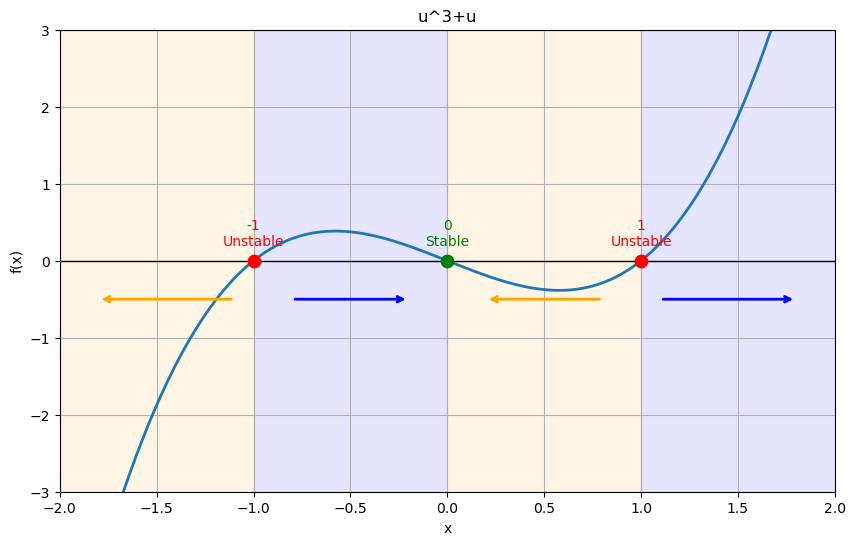

In [4]:
#import numpy as np
#import matplotlib.pyplot as plt

# 定义一维动力系统 dx/dt = f(x)
def f(x):
    return x**3 - x

# 生成 x 范围
x = np.linspace(-2, 2, 500)
y = f(x)

# 找零点（这里直接写出，也可以数值求解）
fixed_points = [-1, 0, 1]

# 判断稳定性
# f'(x) < 0 稳定
# f'(x) > 0 不稳定
def df(x):
    return 3 * x**2 - 1

stability = []
for p in fixed_points:
    if df(p) < 0:
        stability.append("stable")
    else:
        stability.append("unstable")

# 创建图像
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制函数曲线
ax.plot(x, y, label=r'$f(x)=x^3-x$', linewidth=2)
ax.axhline(0, color='black', linewidth=1)

# 标记零点及稳定性
for p, s in zip(fixed_points, stability):
    if s == "stable":
        color = 'green'
        label = 'Stable'
    else:
        color = 'red'
        label = 'Unstable'

    ax.scatter(p, 0, color=color, s=80, zorder=5)
    ax.text(p, 0.2, f'{p}\n{label}', ha='center', color=color)

# 在 x 轴上标出动力系统方向
regions = [(-1.8, -1.1), (-0.8, -0.2), (0.2, 0.8), (1.1, 1.8)]

for a, b in regions:
    mid = (a + b) / 2
    direction = np.sign(f(mid))

    if direction > 0:
        # 向右
        ax.annotate(
            '',
            xy=(b, -0.5),
            xytext=(a, -0.5),
            arrowprops=dict(arrowstyle='->', color='blue', linewidth=2)
        )
    else:
        # 向左
        ax.annotate(
            '',
            xy=(a, -0.5),
            xytext=(b, -0.5),
            arrowprops=dict(arrowstyle='->', color='orange', linewidth=2)
        )

# 给 x 轴动态区域加底色
ax.axvspan(-2, -1, alpha=0.1, color='orange')
ax.axvspan(-1, 0, alpha=0.1, color='blue')
ax.axvspan(0, 1, alpha=0.1, color='orange')
ax.axvspan(1, 2, alpha=0.1, color='blue')

# 设置显示范围
ax.set_xlim(-2, 2)
ax.set_ylim(-3, 3)

# 标签和标题
ax.set_title('u^3+u')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.grid(True)

plt.show()


平衡点:
u = -1.000000, unstable
u = 0.000000, stable
u = 1.000000, unstable


c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34913 (\N{

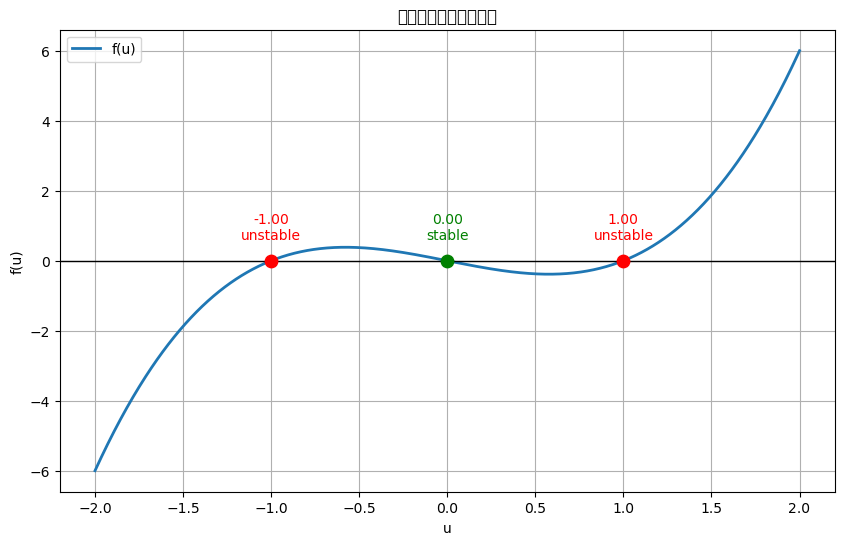

c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\muliy\miniconda3\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


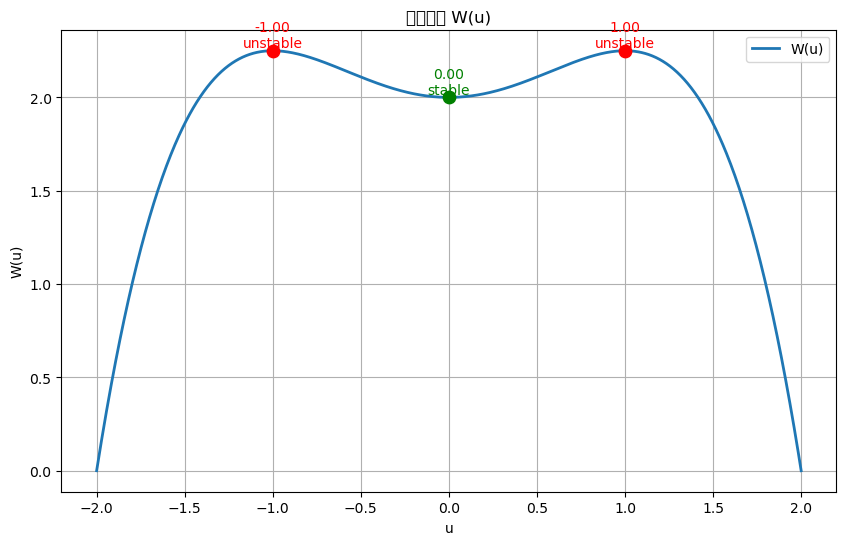

In [5]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import cumulative_trapezoid


class OneDimensionalDynamicalSystem:
    def __init__(self, f, u_range=(-2, 2), params=None, num_points=1000):
        """
        f: 动力系统函数，形式为 f(u, **params)
        u_range: 绘图范围
        params: 函数参数字典
        """
        self.f = f
        self.params = params if params is not None else {}
        self.u_min, self.u_max = u_range
        self.num_points = num_points

        self.u = np.linspace(self.u_min, self.u_max, self.num_points)
        self.f_values = self.f(self.u, **self.params)

        self.fixed_points = self.find_fixed_points()
        self.stability = self.analyze_stability()
        self.W_values = self.compute_potential()

    def find_fixed_points(self, tol=1e-6):
        """寻找 f(u)=0 的平衡点"""
        fixed_points = []

        for i in range(len(self.u) - 1):
            u1, u2 = self.u[i], self.u[i + 1]
            f1, f2 = self.f_values[i], self.f_values[i + 1]

            # 检查是否跨越零点
            if f1 == 0:
                fixed_points.append(u1)
            elif f1 * f2 < 0:
                try:
                    sol = root_scalar(
                        lambda x: self.f(x, **self.params),
                        bracket=[u1, u2],
                        method='brentq'
                    )
                    fixed_points.append(sol.root)
                except ValueError:
                    pass

        # 去掉重复点
        fixed_points = np.array(fixed_points)
        fixed_points = np.unique(np.round(fixed_points, 6))

        return fixed_points

    def numerical_derivative(self, x, h=1e-5):
        return (
            self.f(x + h, **self.params)
            - self.f(x - h, **self.params)
        ) / (2 * h)

    def analyze_stability(self):
        """通过 f'(u*) 判断稳定性"""
        stability = {}

        for fp in self.fixed_points:
            derivative = self.numerical_derivative(fp)
            if derivative < 0:
                stability[fp] = 'stable'
            elif derivative > 0:
                stability[fp] = 'unstable'
            else:
                stability[fp] = 'neutral'

        return stability

    def compute_potential(self):
        """
        势能满足 dW/du = -f(u)
        用数值积分得到 W(u)
        """
        minus_f = -self.f_values
        W = cumulative_trapezoid(minus_f, self.u, initial=0)
        return W

    def plot_phase_line(self, ax, y_position=0):
        """绘制 x 轴上的动力系统流向"""
        intervals = []

        points = [self.u_min] + list(self.fixed_points) + [self.u_max]

        for i in range(len(points) - 1):
            left = points[i]
            right = points[i + 1]
            mid = 0.5 * (left + right)
            intervals.append((left, right, mid))

        for left, right, mid in intervals:
            direction = np.sign(self.f(mid, **self.params))

            if direction > 0:
                color = 'blue'
                ax.annotate(
                    '',
                    xy=(right, y_position),
                    xytext=(left, y_position),
                    arrowprops=dict(arrowstyle='->', color=color, linewidth=2)
                )
            elif direction < 0:
                color = 'orange'
                ax.annotate(
                    '',
                    xy=(left, y_position),
                    xytext=(right, y_position),
                    arrowprops=dict(arrowstyle='->', color=color, linewidth=2)
                )

    def plot_function(self):
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.plot(self.u, self.f_values, linewidth=2, label='f(u)')
        ax.axhline(0, color='black', linewidth=1)

        for fp in self.fixed_points:
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, 0, color=color, s=80, zorder=5)
            ax.text(
                fp,
                0.05 * (np.max(self.f_values) - np.min(self.f_values)),
                f'{fp:.2f}\n{stability}',
                ha='center',
                color=color
            )

        y_phase = np.min(self.f_values) - 0.15 * (
            np.max(self.f_values) - np.min(self.f_values)
        )

        self.plot_phase_line(ax, y_position=y_phase)

        ax.set_title('动力系统函数与平衡点')
        ax.set_xlabel('u')
        ax.set_ylabel('f(u)')
        ax.grid(True)
        ax.legend()

        plt.show()

    def plot_potential(self):
        fig, ax = plt.subplots(figsize=(10, 6))

        ax.plot(self.u, self.W_values, linewidth=2, label='W(u)')

        for fp in self.fixed_points:
            W_fp = np.interp(fp, self.u, self.W_values)
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, W_fp, color=color, s=80, zorder=5)
            ax.text(
                fp,
                W_fp,
                f'{fp:.2f}\n{stability}',
                ha='center',
                va='bottom',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        self.plot_phase_line(ax, y_position=y_phase)

        ax.set_title('势能函数 W(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('W(u)')
        ax.grid(True)
        ax.legend()

        plt.show()


# =========================
# 使用示例
# =========================

# 例子：du/dt = u^3 - u
# 可替换为任意含参数函数

def f(u, a=1):
    return u**3 - a * u


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-2, 2),
    params={'a': 1}
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function()
system.plot_potential()


平衡点:
u = -1.000000, unstable
u = 0.000000, stable
u = 1.000000, unstable


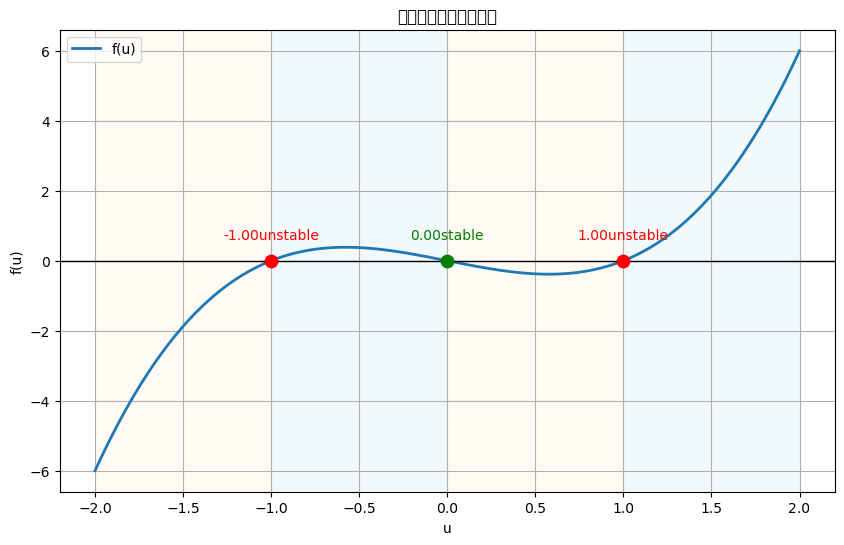

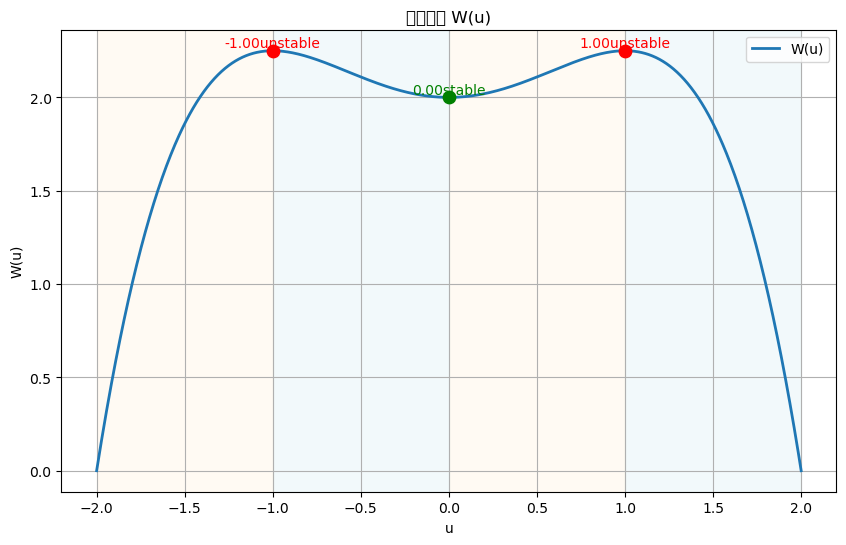

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import cumulative_trapezoid


class OneDimensionalDynamicalSystem:
    def __init__(self, f, u_range=(-2, 2), params=None, num_points=1000):
        """
        f: 动力系统函数，形式为 f(u, **params)
        u_range: 绘图范围
        params: 函数参数字典
        """
        self.f = f
        self.params = params if params is not None else {}
        self.u_min, self.u_max = u_range
        self.num_points = num_points

        self.u = np.linspace(self.u_min, self.u_max, self.num_points)
        self.f_values = self.f(self.u, **self.params)

        self.fixed_points = self.find_fixed_points()
        self.stability = self.analyze_stability()
        self.W_values = self.compute_potential()

    def find_fixed_points(self, tol=1e-6):
        """寻找 f(u)=0 的平衡点"""
        fixed_points = []

        for i in range(len(self.u) - 1):
            u1, u2 = self.u[i], self.u[i + 1]
            f1, f2 = self.f_values[i], self.f_values[i + 1]

            # 检查是否跨越零点
            if f1 == 0:
                fixed_points.append(u1)
            elif f1 * f2 < 0:
                try:
                    sol = root_scalar(
                        lambda x: self.f(x, **self.params),
                        bracket=[u1, u2],
                        method='brentq'
                    )
                    fixed_points.append(sol.root)
                except ValueError:
                    pass

        # 去掉重复点
        fixed_points = np.array(fixed_points)
        fixed_points = np.unique(np.round(fixed_points, 6))

        return fixed_points

    def numerical_derivative(self, x, h=1e-5):
        return (
            self.f(x + h, **self.params)
            - self.f(x - h, **self.params)
        ) / (2 * h)

    def analyze_stability(self):
        """通过 f'(u*) 判断稳定性"""
        stability = {}

        for fp in self.fixed_points:
            derivative = self.numerical_derivative(fp)
            if derivative < 0:
                stability[fp] = 'stable'
            elif derivative > 0:
                stability[fp] = 'unstable'
            else:
                stability[fp] = 'neutral'

        return stability

    def compute_potential(self):
        """
        势能满足 dW/du = -f(u)
        用数值积分得到 W(u)
        """
        minus_f = -self.f_values
        W = cumulative_trapezoid(minus_f, self.u, initial=0)
        return W

    def plot_phase_line(self, ax, y_position=0):
        """绘制 x 轴上的动力系统流向，并给不同区域添加底色"""
        points = [self.u_min] + list(self.fixed_points) + [self.u_max]

        region_colors = {
            1: 'lightblue',
            -1: 'moccasin'
        }

        for i in range(len(points) - 1):
            left = points[i]
            right = points[i + 1]
            mid = 0.5 * (left + right)

            direction = np.sign(self.f(mid, **self.params))

            # 添加区域底色
            if direction != 0:
                ax.axvspan(
                    left,
                    right,
                    alpha=0.15,
                    color=region_colors.get(direction, 'lightgray')
                )

            # 绘制箭头
            if direction > 0:
                ax.annotate(
                    '',
                    xy=(right, y_position),
                    xytext=(left, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='blue',
                        linewidth=2
                    )
                )
            elif direction < 0:
                ax.annotate(
                    '',
                    xy=(left, y_position),
                    xytext=(right, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='orange',
                        linewidth=2
                    )
                )

    def plot_function(self, ax=None, figsize=(10, 6), xlim=None, ylim=None):
        """
        绘制函数图像。
        如果传入 ax，则画在已有坐标轴上；否则自动创建。
        """
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.f_values, linewidth=2, label='f(u)')
        ax.axhline(0, color='black', linewidth=1)

        for fp in self.fixed_points:
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, 0, color=color, s=80, zorder=5)
            ax.text(
                fp,
                0.05 * (np.max(self.f_values) - np.min(self.f_values)),
                f'{fp:.2f}{stability}',
                ha='center',
                color=color
            )

        y_phase = np.min(self.f_values) - 0.15 * (
            np.max(self.f_values) - np.min(self.f_values)
        )

        self.plot_phase_line(ax, y_position=y_phase)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title('动力系统函数与平衡点')
        ax.set_xlabel('u')
        ax.set_ylabel('f(u)')
        ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()

    def plot_potential(self, ax=None, figsize=(10, 6), xlim=None, ylim=None):
        """
        绘制势能函数图像。
        如果传入 ax，则画在已有坐标轴上；否则自动创建。
        """
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.W_values, linewidth=2, label='W(u)')

        for fp in self.fixed_points:
            W_fp = np.interp(fp, self.u, self.W_values)
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, W_fp, color=color, s=80, zorder=5)
            ax.text(
                fp,
                W_fp,
                f'{fp:.2f}{stability}',
                ha='center',
                va='bottom',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        self.plot_phase_line(ax, y_position=y_phase)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title('势能函数 W(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('W(u)')
        ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()


# =========================
# 使用示例
# =========================

# 例子：du/dt = u^3 - u
# 可替换为任意含参数函数

def f(u, a=1):
    return u**3 - a * u


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-2, 2),
    params={'a': 1}
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function()
system.plot_potential()

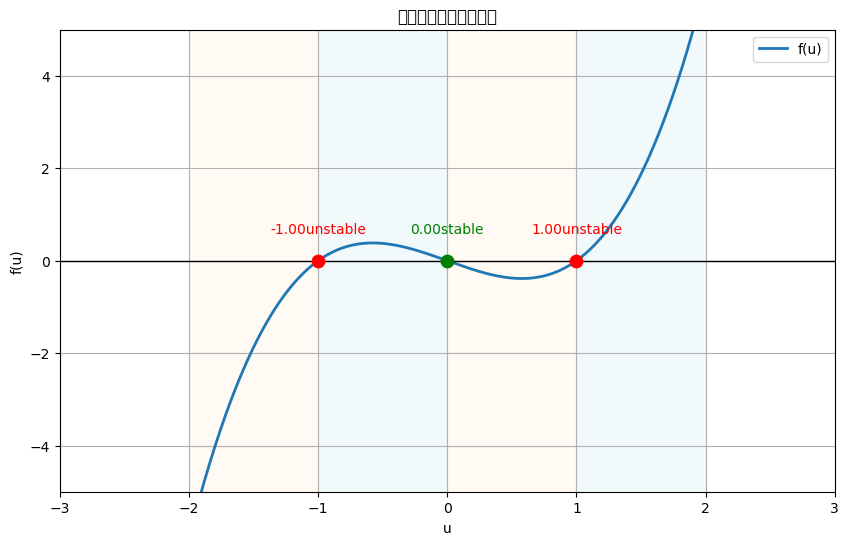

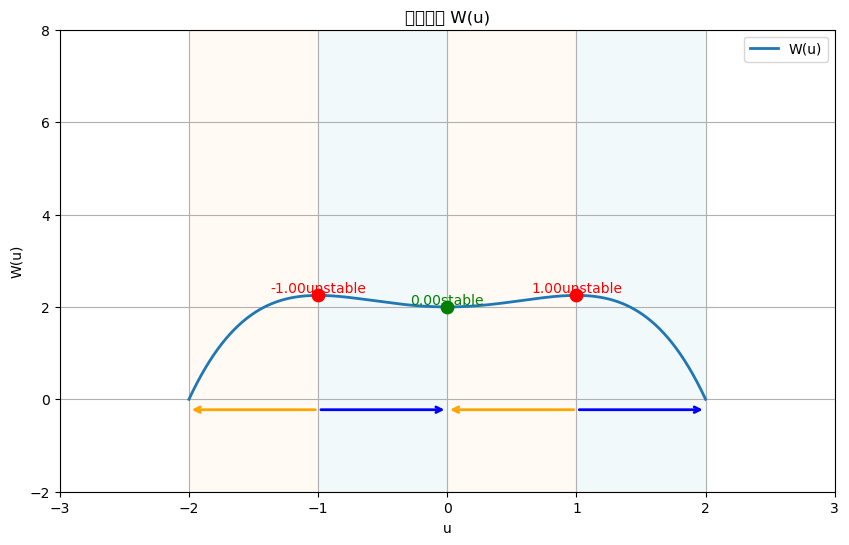

In [14]:
system.plot_function(
    xlim=(-3, 3),
    ylim=(-5, 5)
)

system.plot_potential(
    xlim=(-3, 3),
    ylim=(-2, 8)
)

平衡点:
u = 0.000000, stable
u = 0.500000, unstable
u = 1.000000, stable


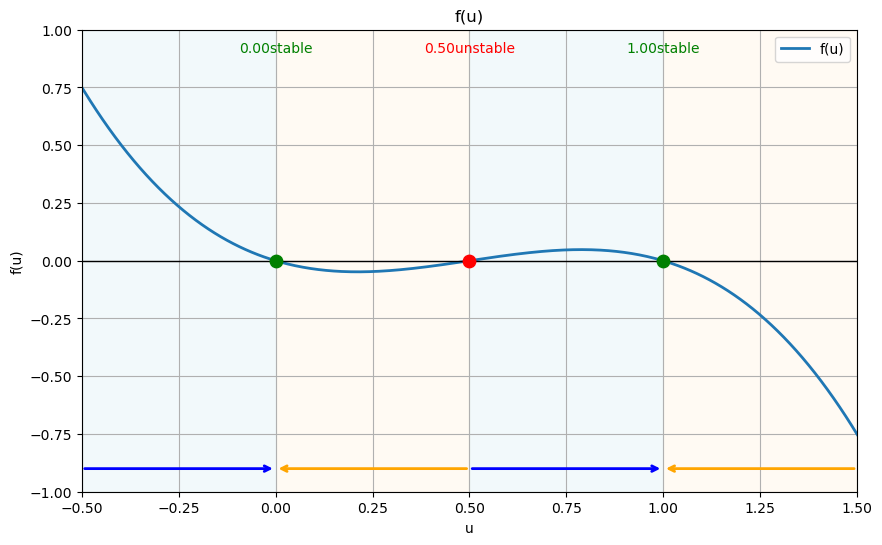

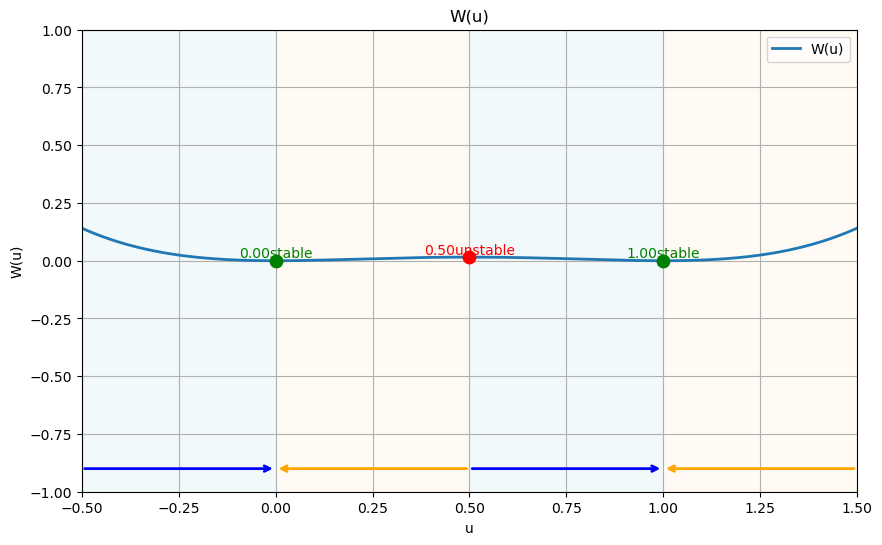

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from scipy.integrate import cumulative_trapezoid


class OneDimensionalDynamicalSystem:
    def __init__(self, f, u_range=(-2, 2), params=None, num_points=1000):
        """
        f: 动力系统函数，形式为 f(u, **params)
        u_range: 绘图范围
        params: 函数参数字典
        """
        self.f = f
        self.params = params if params is not None else {}
        self.u_min, self.u_max = u_range
        self.num_points = num_points

        self.u = np.linspace(self.u_min, self.u_max, self.num_points)
        self.f_values = self.f(self.u, **self.params)

        self.fixed_points = self.find_fixed_points()
        self.stability = self.analyze_stability()
        self.W_values = self.compute_potential()

    def find_fixed_points(self, tol=1e-6):
        """寻找 f(u)=0 的平衡点"""
        fixed_points = []

        for i in range(len(self.u) - 1):
            u1, u2 = self.u[i], self.u[i + 1]
            f1, f2 = self.f_values[i], self.f_values[i + 1]

            # 检查是否跨越零点
            if f1 == 0:
                fixed_points.append(u1)
            elif f1 * f2 < 0:
                try:
                    sol = root_scalar(
                        lambda x: self.f(x, **self.params),
                        bracket=[u1, u2],
                        method='brentq'
                    )
                    fixed_points.append(sol.root)
                except ValueError:
                    pass

        # 去掉重复点
        fixed_points = np.array(fixed_points)
        fixed_points = np.unique(np.round(fixed_points, 6))

        return fixed_points

    def numerical_derivative(self, x, h=1e-5):
        return (
            self.f(x + h, **self.params)
            - self.f(x - h, **self.params)
        ) / (2 * h)

    def analyze_stability(self):
        """通过 f'(u*) 判断稳定性"""
        stability = {}

        for fp in self.fixed_points:
            derivative = self.numerical_derivative(fp)
            if derivative < 0:
                stability[fp] = 'stable'
            elif derivative > 0:
                stability[fp] = 'unstable'
            else:
                stability[fp] = 'neutral'

        return stability

    
    
    def compute_potential(self):
        minus_f = -self.f_values
        W = cumulative_trapezoid(minus_f, self.u, initial=0)
        W0 = np.interp(0, self.u, W)
        W -= W0
        return W

    def plot_phase_line(self, ax, y_position=0, x_range=None):
        """绘制 x 轴上的动力系统流向，并给不同区域添加底色"""
        if x_range is None:
            x_min, x_max = self.u_min, self.u_max
        else:
            x_min, x_max = x_range

        visible_fixed_points = [fp for fp in self.fixed_points if x_min < fp < x_max]
        points = [x_min] + list(visible_fixed_points) + [x_max]

        region_colors = {
            1: 'lightblue',
            -1: 'moccasin'
        }

        for i in range(len(points) - 1):
            left = points[i]
            right = points[i + 1]
            mid = 0.5 * (left + right)

            direction = np.sign(self.f(mid, **self.params))

            # 添加区域底色
            if direction != 0:
                ax.axvspan(
                    left,
                    right,
                    alpha=0.15,
                    color=region_colors.get(direction, 'lightgray')
                )

            # 绘制箭头
            if direction > 0:
                ax.annotate(
                    '',
                    xy=(right, y_position),
                    xytext=(left, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='blue',
                        linewidth=2
                    )
                )
            elif direction < 0:
                ax.annotate(
                    '',
                    xy=(left, y_position),
                    xytext=(right, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='orange',
                        linewidth=2
                    )
                )

    def plot_function(self, ax=None, figsize=(10, 6), xlim=None, ylim=None):
        """
        绘制函数图像。
        如果传入 ax，则画在已有坐标轴上；否则自动创建。
        """
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.f_values, linewidth=2, label='f(u)')
        ax.axhline(0, color='black', linewidth=1)

        for fp in self.fixed_points:
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, 0, color=color, s=80, zorder=5)
            ax.text(
                fp,
                0.05 * (np.max(self.f_values) - np.min(self.f_values)),
                f'{fp:.2f}{stability}',
                ha='center',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        phase_x_range = xlim if xlim is not None else (self.u_min, self.u_max)
        self.plot_phase_line(ax, y_position=y_phase, x_range=phase_x_range)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title('f(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('f(u)')
        ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()

    def plot_potential(self, ax=None, figsize=(10, 6), xlim=None, ylim=None):
        """
        绘制势能函数图像。
        如果传入 ax，则画在已有坐标轴上；否则自动创建。
        """
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.W_values, linewidth=2, label='W(u)')

        for fp in self.fixed_points:
            W_fp = np.interp(fp, self.u, self.W_values)
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, W_fp, color=color, s=80, zorder=5)
            ax.text(
                fp,
                W_fp,
                f'{fp:.2f}{stability}',
                ha='center',
                va='bottom',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        phase_x_range = xlim if xlim is not None else (self.u_min, self.u_max)
        self.plot_phase_line(ax, y_position=y_phase, x_range=phase_x_range)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title('W(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('W(u)')
        ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()


# =========================
# 使用示例
# =========================


def f(u, a=0.5):
    return u*(1-u)*(u-a)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-2, 2),
    params={'a': 0.5}
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-0.5,1.5),ylim=(-1,1))
system.plot_potential(xlim=(-0.5,1.5),ylim=(-1,1))

平衡点:
u = 0.000000, unstable
u = 1.000000, stable


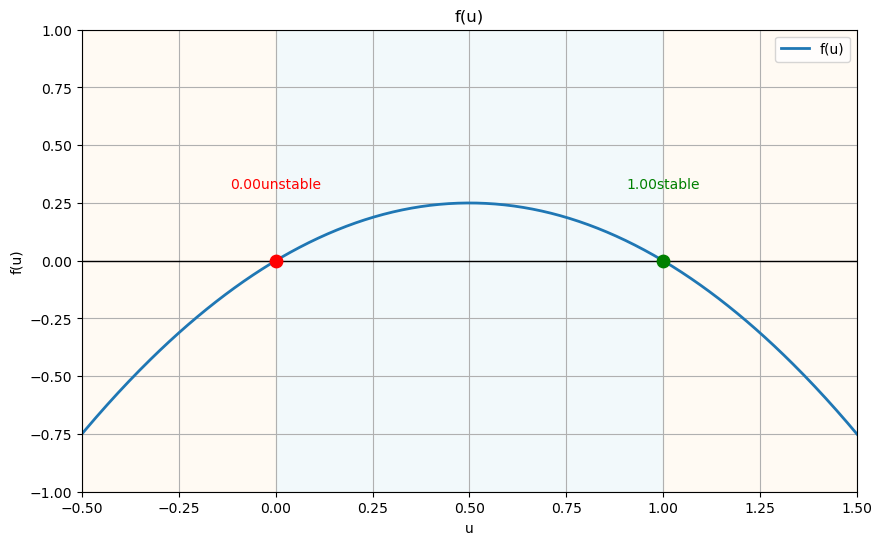

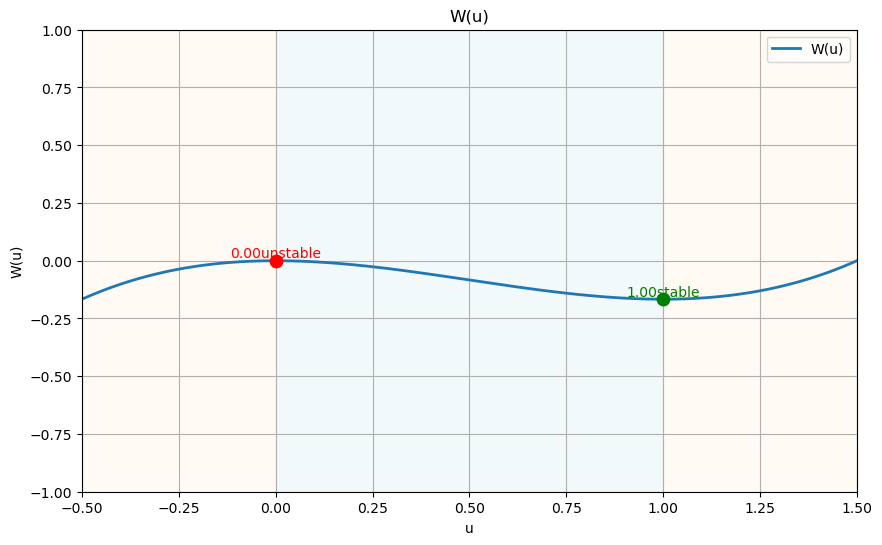

In [30]:
def f(u):
    return u*(1-u)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-2, 2)
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-0.5,1.5),ylim=(-1,1))
system.plot_potential(xlim=(-0.5,1.5),ylim=(-1,1))

平衡点:
u = -1.000000, stable
u = 0.000000, unstable
u = 1.000000, stable


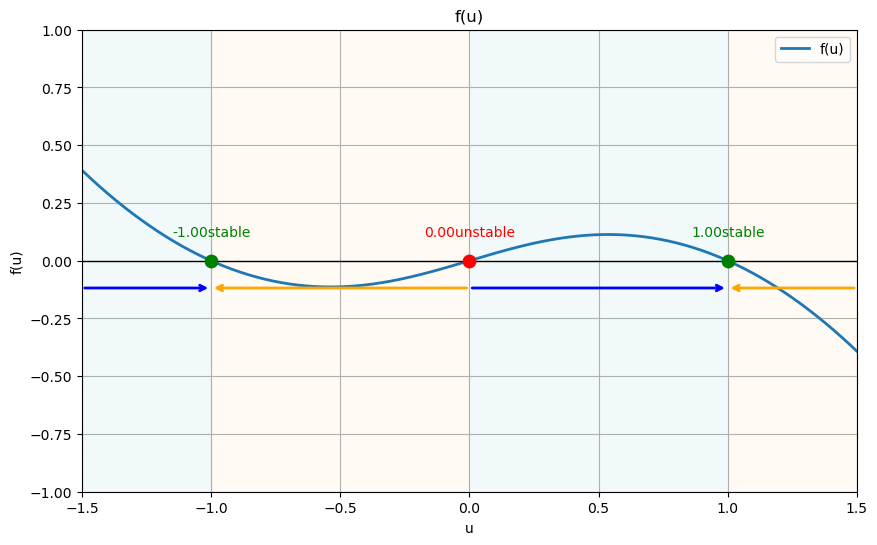

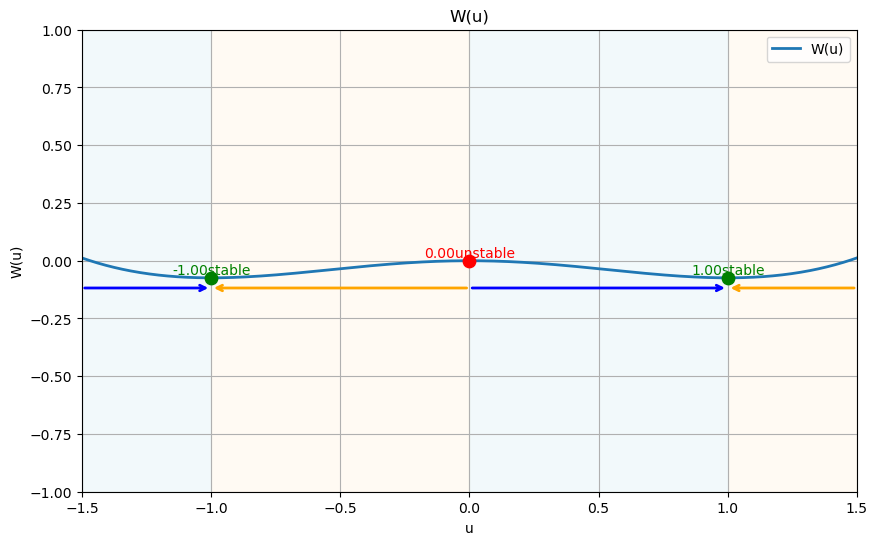

In [37]:
def f(u):
    return u*(1-(1+np.sqrt(1+3*u**2))/3)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-2, 2)
)

print('平衡点:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-1.5,1.5),ylim=(-1,1))
system.plot_potential(xlim=(-1.5,1.5),ylim=(-1,1))

In [10]:
from sympy import *

In [13]:
x, y, z = symbols('x y z')
y = expand((x + z+ 1)**4) # expand() 是展开函数
y

x**4 + 4*x**3*z + 4*x**3 + 6*x**2*z**2 + 12*x**2*z + 6*x**2 + 4*x*z**3 + 12*x*z**2 + 12*x*z + 4*x + z**4 + 4*z**3 + 6*z**2 + 4*z + 1

In [ ]:

z = Rational(1.5, 2) # 构造分数 1/2
z

3/4

In [24]:
x = symbols('x')
expr = cos(x) + 1
expr.subs(x, 0)
expr

cos(x) + 1

In [26]:
solveset(x*(1-x)*(x-0.5),x)

{0, 0.5, 1}